# Exploratory Data Analysis (EDA)

## Diabetes Dataset Analysis  
**Course:** Machine Learning Lab  
**Student Name:** Reema AlMulla  
**Dataset:** Pima Indians Diabetes Dataset  

---

## Introduction

This notebook presents an Exploratory Data Analysis (EDA) of the Diabetes dataset.  
The purpose of this analysis is to understand the structure, distributions, relationships, and key characteristics of the data before applying machine learning techniques.

The dataset contains medical information about patients, including features such as glucose level, blood pressure, BMI, age, and insulin level. The target variable (Outcome) indicates whether a patient has diabetes (1) or not (0).

Through data cleaning, visualization, and correlation analysis, this notebook aims to identify important patterns and potential predictors of diabetes.



## Objectives

- Understand the structure and summary statistics of the dataset
- Handle missing or unrealistic values
- Analyze distributions of medical features
- Examine relationships between variables
- Identify features strongly associated with diabetes outcome

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
df.shape

(768, 9)

In [4]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [6]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [7]:
(df == 0).sum()

Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64

In [8]:
cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

df[cols] = df[cols].replace(0, np.nan)

df.isnull().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

In [9]:
for col in cols:
    df[col] = df[col].fillna(df[col].median())

df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

## Distribution of Features
The following histograms show the distribution of all numerical variables in the dataset.

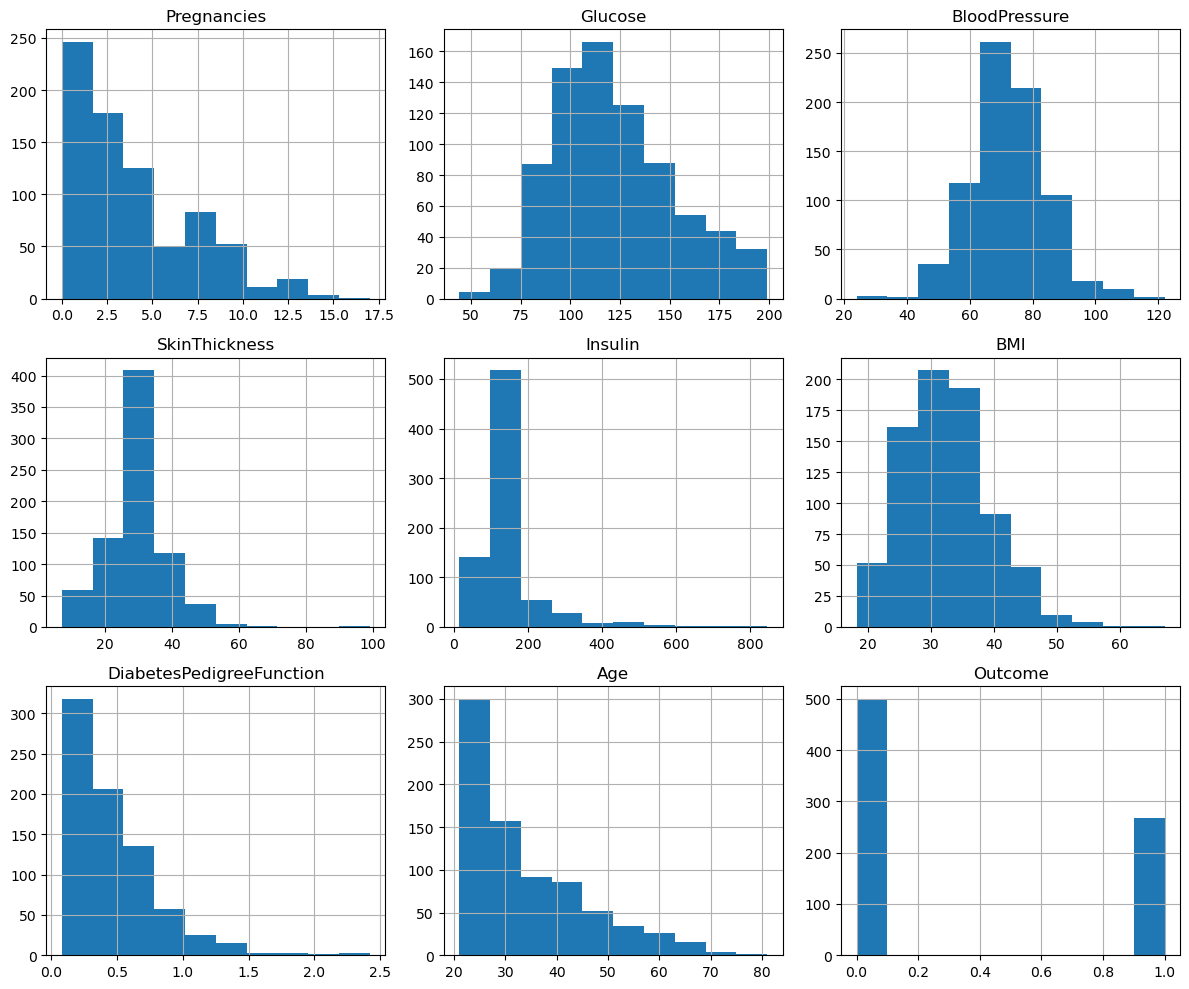

In [10]:
df.hist(figsize=(12,10))
plt.tight_layout()
plt.show()

Insulin appears highly right-skewed, indicating the presence of extreme values and outliers.

## Correlation Analysis
The heatmap below shows the correlation between all numerical variables.

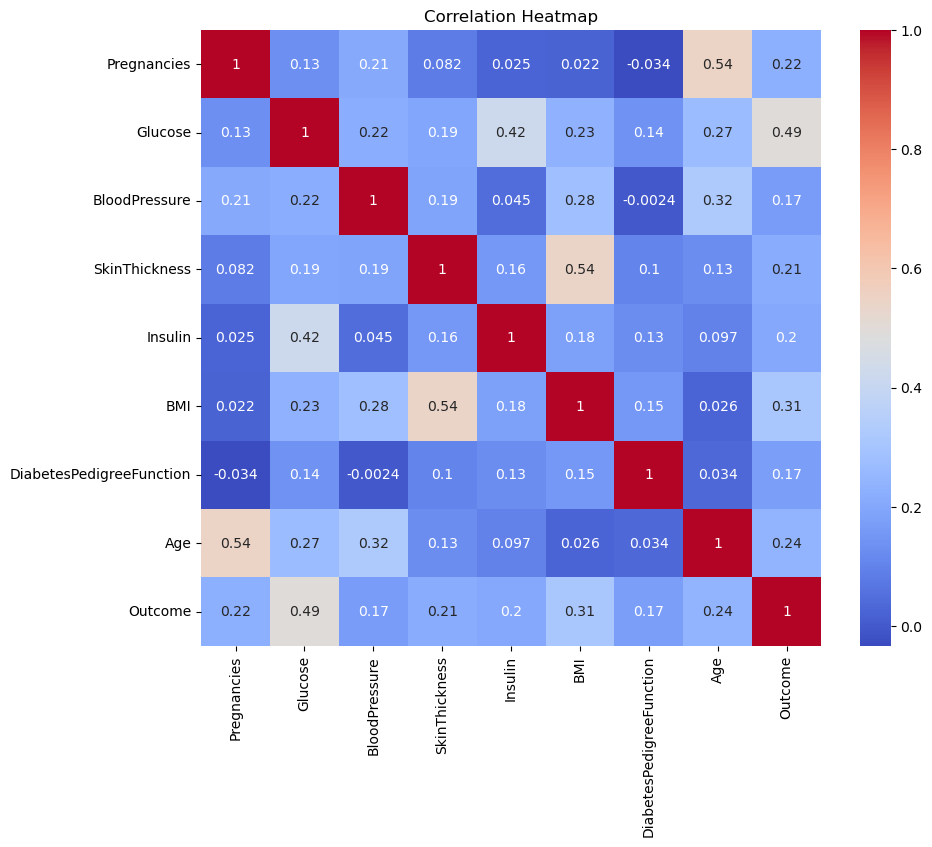

In [11]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

### Correlation Insights

- Glucose has the strongest positive correlation with diabetes outcome (0.49).
- BMI also shows a moderate positive correlation (0.31).
- Age and Pregnancies have weaker positive correlations.
- BloodPressure and Insulin show relatively low correlation with the outcome.

This suggests that Glucose level is the most important predictor of diabetes in this dataset.

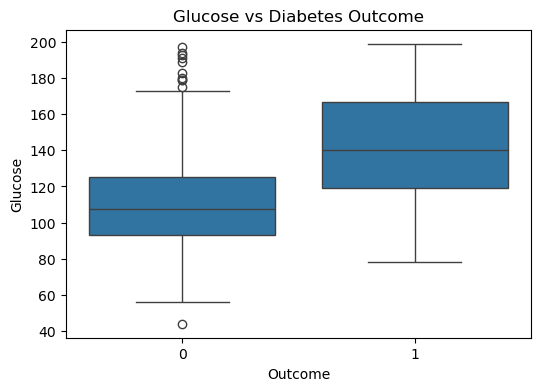

In [12]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Outcome", y="Glucose", data=df)
plt.title("Glucose vs Diabetes Outcome")
plt.show()

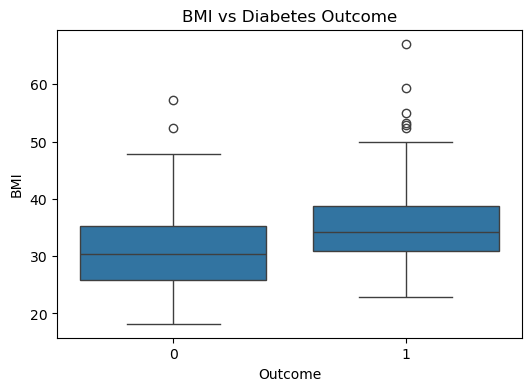

In [13]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Outcome", y="BMI", data=df)
plt.title("BMI vs Diabetes Outcome")
plt.show()

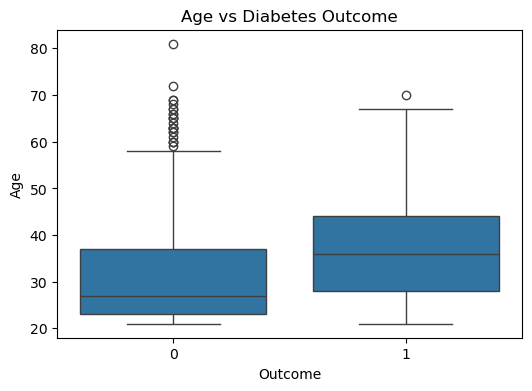

In [14]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Outcome", y="Age", data=df)
plt.title("Age vs Diabetes Outcome")
plt.show()

## Key Findings

- The dataset contains 768 samples and 9 features.
- Several medical variables originally contained zero values that were treated as missing and replaced using median imputation.
- Insulin shows strong right skewness with noticeable outliers.
- Glucose has the strongest positive correlation with diabetes outcome (0.49).
- BMI and Age also show moderate positive relationships with diabetes.
- Boxplots clearly show higher Glucose and BMI values among diabetic patients.
- The dataset is slightly imbalanced, with more non-diabetic cases than diabetic cases.

## Conclusion

Exploratory Data Analysis revealed that Glucose level is the most significant predictor of diabetes in this dataset. BMI and Age also contribute moderately to diabetes risk. After handling missing values and visualizing distributions and correlations, the dataset is now ready for machine learning modeling.